!pip install \
pandas==2.3.3 \
numpy==2.4.2 \
requests==2.32.3 \
matplotlib==3.9.2 \
seaborn==0.13.2 \
plotly==5.24.1 \
scikit-learn==1.6.1 \
xgboost==3.0.2 \
lightgbm==4.6.0 \
catboost==1.2.8 \
optuna==4.3.0

In [1]:
import sys

# Core
import pandas as pd
import numpy as np
import math
import requests

# Visualization
import matplotlib
import seaborn as sns
import plotly

# ML
import sklearn
import xgboost
import lightgbm
import catboost

# Optimization
import optuna

# Print versions
print("Python:", sys.version)

# Core
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("math: built-in")
print("requests:", requests.__version__)

# Visualization
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("plotly:", plotly.__version__)

# ML
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)
print("catboost:", catboost.__version__)

# Optimization
print("optuna:", optuna.__version__)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas: 2.3.3
numpy: 2.0.2
math: built-in
requests: 2.32.4
matplotlib: 3.10.0
seaborn: 0.13.2
plotly: 5.24.1
scikit-learn: 1.6.1
xgboost: 3.2.0
lightgbm: 4.6.0
catboost: 1.2.10
optuna: 4.8.0


In [2]:
# =========================
# Core
# =========================
import math
import requests
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly.offline import init_notebook_mode, plot, iplot, download_plotlyjs

# =========================
# ML / Preprocessing
# =========================
from sklearn.model_selection import KFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# =========================
# Metrics
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# Models
# =========================
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================
# Optimization
# =========================
import optuna

In [ ]:
df = pd.read_csv("./Dataset/used_cars_clean.csv")

In [4]:
def fe_transform(df_raw, current_year=2020):
    df = df_raw.copy()

    for c in ["year", "mileage", "engineSize", "tax", "mpg", "price"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # -------------------------
    # Basic Features
    # -------------------------
    if "year" in df.columns:
        df["vehicle_age"] = current_year - df["year"]
        df["CAE"] = np.log1p(df["vehicle_age"].clip(lower=0))

    if "mileage" in df.columns:
        df["log_mileage"] = np.log1p(df["mileage"].clip(lower=0))

    if "mileage" in df.columns and "vehicle_age" in df.columns:
        df["km_per_year"] = df["mileage"] / (df["vehicle_age"] + 1)

    if "log_mileage" in df.columns and "CAE" in df.columns:
        df["mileage_age_interaction"] = df["log_mileage"] * df["CAE"]

    # -------------------------
    # Binary features
    # -------------------------
    if "mileage" in df.columns:
        df["high_mileage"] = (df["mileage"] > 100_000).astype(int)

    if "engineSize" in df.columns:
        df["large_engine"] = (df["engineSize"] >= 2.0).astype(int)

    if "transmission" in df.columns and "engineSize" in df.columns:
        df["auto_large_engine"] = (
            (df["transmission"].astype(str) == "Automatic") & (df["engineSize"] >= 2.0)
        ).astype(int)

    # -------------------------
    # Brand Aggregations
    # -------------------------
    if "brand" in df.columns and "price" in df.columns:

        brand_price_mean = df.groupby("brand")["price"].mean()
        brand_price_std = df.groupby("brand")["price"].std()

        df["brand_price_mean"] = df["brand"].map(brand_price_mean)
        df["brand_price_std"] = df["brand"].map(brand_price_std)

    if "brand" in df.columns and "mileage" in df.columns:

        brand_mileage_mean = df.groupby("brand")["mileage"].mean()
        df["brand_mileage_mean"] = df["brand"].map(brand_mileage_mean)

    # -------------------------
    # Target
    # -------------------------
    if "price" in df.columns:
        df["log_price"] = np.log1p(df["price"])

    return df

## Model Training and Hyperparameter Optimization

This stage of the project focuses on building, tuning, and comparing several regression models for used car price prediction.

### 1. Data Preparation

The dataset is first filtered to keep only valid target values where `price > 0`.  
After that, a custom feature engineering function `fe_transform(df)` is applied to create additional predictive variables such as:

- `CAE`
- `log_mileage`
- `km_per_year`
- `mileage_age_interaction`
- `high_mileage`
- `large_engine`
- `auto_large_engine`

The prediction target is defined as:

- `log_price`

A logarithmic target is used because car prices are usually right-skewed, and log transformation helps stabilize variance and makes the regression problem easier to model.

### 2. Feature Groups

The input features are divided into two groups:

**Numerical features**
- `CAE`
- `log_mileage`
- `km_per_year`
- `engineSize`
- `mpg`
- `tax`
- `mileage_age_interaction`
- `high_mileage`
- `large_engine`
- `auto_large_engine`

**Categorical features**
- `brand`
- `model`
- `transmission`
- `fuelType`

Only the columns that actually exist in the dataset are kept.

### 3. Preprocessing Pipeline

Before training, the data is passed through a preprocessing pipeline:

- **Numerical columns** are imputed using the **median**
- **Categorical columns** are imputed using the **most frequent value**
- Categorical variables are transformed using **One-Hot Encoding**

This preprocessing is wrapped inside a `ColumnTransformer` so that every model is trained on the same transformed input space.

### 4. Cross-Validation Strategy

To evaluate model performance consistently, the training process uses:

- **K-Fold Cross-Validation**
- `n_splits = 5`
- `shuffle = True`
- `random_state = 42`

This means the dataset is split into 5 folds, and each model is trained and validated 5 times on different subsets of the data.

### 5. Hyperparameter Optimization with Optuna

Each model is tuned using **Optuna**, an automatic hyperparameter optimization framework.

The objective for every trial is to minimize:

- **RMSE on log-price**  
using cross-validation.

The scoring metric used inside Optuna is:

- `neg_root_mean_squared_error`

Since scikit-learn returns negative values for loss-based scorers, the sign is inverted so that Optuna minimizes the true RMSE.

### 6. Models Trained

The following regression models are optimized and compared:

#### Decision Tree Regressor
Tuned hyperparameters:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

#### Random Forest Regressor
Tuned hyperparameters:
- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

#### XGBoost Regressor
Tuned hyperparameters:
- `n_estimators`
- `learning_rate`
- `max_depth`
- `subsample`
- `colsample_bytree`
- `reg_lambda`
- `min_child_weight`

#### LightGBM Regressor
Tuned hyperparameters:
- `n_estimators`
- `learning_rate`
- `num_leaves`
- `max_depth`
- `subsample`
- `colsample_bytree`
- `reg_lambda`
- `min_child_samples`

#### CatBoost Regressor
Tuned hyperparameters:
- `iterations`
- `learning_rate`
- `depth`
- `l2_leaf_reg`

### 7. Final Model Comparison

After Optuna finds the best hyperparameters for each model, the tuned versions are compared again using manual 5-fold cross-validation.

For each fold, the following metrics are calculated:

#### Metrics on log scale
- **RMSE_log**
- **MAE_log**
- **R²_log**

#### Metrics on real price scale
Predictions and targets are transformed back using `expm1`, then the following are computed:

- **RMSE_real**
- **MAE_real**
- **R²_real**

This gives both:
- a mathematically stable evaluation on the log scale
- a business-friendly evaluation in actual currency values

### 8. Model Selection

The final ranking is based on:

- **RMSE_real_mean**

This metric is chosen because it is easier to interpret in real-world terms, showing average prediction error directly in price units rather than logarithmic units.

The best-performing model is then selected and retrained on the full dataset.

### 9. Final Training

Once the best model is identified:

- the full preprocessing pipeline is combined with the best regressor
- the final pipeline is fitted on the entire dataset
- this trained pipeline becomes the final model artifact for deployment or further evaluation

### 10. Why This Training Design Is Strong

This training setup is strong because it ensures:

- consistent preprocessing across all models
- fair comparison between algorithms
- automatic hyperparameter tuning
- robust validation through cross-validation
- evaluation both in log space and real price space
- final model selection based on business-relevant error

In [5]:
# Data and feature engineering
target_col = "price"
random_seed = 42
n_splits = 5
shuffle = True
n_trials = 10

df = df[df[target_col].notna() & (df[target_col] > 0)].copy()
df = fe_transform(df)

target = "log_price"
y = df[target].copy()

num_cols = [
    "CAE", "log_mileage", "km_per_year", "engineSize", "mpg", "tax",
    "mileage_age_interaction", "high_mileage", "large_engine", "auto_large_engine"
]
cat_cols = ["brand", "model", "transmission", "fuelType"]

num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

X = df[num_cols + cat_cols].copy()

mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)


def rmse(a, b):
    return math.sqrt(mean_squared_error(a, b))


# Preprocessing
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)


# Cross-validation setup
kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_seed)


# Optuna objective functions
def objective_decision_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": random_seed
    }

    model = DecisionTreeRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", model)
    ])

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()


def objective_random_forest(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": random_seed,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", model)
    ])

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()


def objective_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "objective": "reg:squarederror",
        "random_state": random_seed,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", model)
    ])

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()


def objective_lightgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 255),
        "max_depth": trial.suggest_int("max_depth", -1, 16),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state": random_seed,
        "verbosity": -1
    }

    model = LGBMRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", model)
    ])

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()


def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2500, step=250),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "random_seed": random_seed,
        "loss_function": "RMSE",
        "verbose": False
    }

    model = CatBoostRegressor(**params)

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", model)
    ])

    scores = cross_val_score(
        pipe, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()


# Run Optuna for each model
studies = {}

studies["DecisionTree"] = optuna.create_study(direction="minimize")
studies["DecisionTree"].optimize(objective_decision_tree, n_trials=n_trials)

studies["RandomForest"] = optuna.create_study(direction="minimize")
studies["RandomForest"].optimize(objective_random_forest, n_trials=n_trials)

studies["XGBoost"] = optuna.create_study(direction="minimize")
studies["XGBoost"].optimize(objective_xgboost, n_trials=n_trials)

studies["LightGBM"] = optuna.create_study(direction="minimize")
studies["LightGBM"].optimize(objective_lightgbm, n_trials=n_trials)

studies["CatBoost"] = optuna.create_study(direction="minimize")
studies["CatBoost"].optimize(objective_catboost, n_trials=n_trials)


# Build models with best hyperparameters
models = {
    "DecisionTree": DecisionTreeRegressor(**studies["DecisionTree"].best_params, random_state=random_seed),
    "RandomForest": RandomForestRegressor(**studies["RandomForest"].best_params, random_state=random_seed, n_jobs=-1),
    "XGBoost": XGBRegressor(**studies["XGBoost"].best_params, objective="reg:squarederror", random_state=random_seed, n_jobs=-1),
    "LightGBM": LGBMRegressor(**studies["LightGBM"].best_params, random_state=random_seed, verbosity=-1),
    "CatBoost": CatBoostRegressor(**studies["CatBoost"].best_params, loss_function="RMSE", random_seed=random_seed, verbose=False),
}


# Compare tuned models with manual CV
all_rows = []

for model_name, reg in models.items():
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pipe = Pipeline([
            ("preprocess", preprocessor),
            ("regressor", reg)
        ])

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_va)

        row = {
            "model": model_name,
            "fold": fold,
            "RMSE_log": rmse(y_va, y_pred),
            "MAE_log": mean_absolute_error(y_va, y_pred),
            "R2_log": r2_score(y_va, y_pred),
        }

        yt = np.expm1(y_va.to_numpy())
        yp = np.expm1(np.array(y_pred))

        row.update({
            "RMSE_real": rmse(yt, yp),
            "MAE_real": mean_absolute_error(yt, yp),
            "R2_real": r2_score(yt, yp),
        })

        all_rows.append(row)

cv_df = pd.DataFrame(all_rows)


# Aggregate results
summary_df = (
    cv_df
    .groupby("model")
    .agg(
        RMSE_log_mean=("RMSE_log", "mean"),
        RMSE_log_std=("RMSE_log", "std"),
        MAE_log_mean=("MAE_log", "mean"),
        MAE_log_std=("MAE_log", "std"),
        R2_log_mean=("R2_log", "mean"),
        R2_log_std=("R2_log", "std"),
        RMSE_real_mean=("RMSE_real", "mean"),
        RMSE_real_std=("RMSE_real", "std"),
        MAE_real_mean=("MAE_real", "mean"),
        MAE_real_std=("MAE_real", "std"),
        R2_real_mean=("R2_real", "mean"),
        R2_real_std=("R2_real", "std"),
    )
    .reset_index()
)

summary_df = summary_df.sort_values("RMSE_real_mean", ascending=True).reset_index(drop=True)

print("CV Summary")
display(summary_df)

print("CV Folds")
display(cv_df.sort_values(["model", "fold"]))


# Train final best model on full data
best_model_name = summary_df.loc[0, "model"]
best_reg = models[best_model_name]

best_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", best_reg)
])

best_pipe.fit(X, y)

print(f"Best model: {best_model_name}")
best_pipe

[I 2026-04-17 20:30:31,409] A new study created in memory with name: no-name-2d52116b-4a12-4fbc-93f1-6f9f76c94bef
[I 2026-04-17 20:30:38,316] Trial 0 finished with value: 0.12659932097978338 and parameters: {'max_depth': 17, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.12659932097978338.
[I 2026-04-17 20:30:43,562] Trial 1 finished with value: 0.12267404156434163 and parameters: {'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.12267404156434163.
[I 2026-04-17 20:30:47,898] Trial 2 finished with value: 0.16333576206937067 and parameters: {'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.12267404156434163.
[I 2026-04-17 20:30:52,841] Trial 3 finished with value: 0.12603553807474452 and parameters: {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.12267404156434163.
[I 2026-04-17 20:30:57,710] Trial 4 finished with val

CV Summary


,model,RMSE_log_mean,RMSE_log_std,MAE_log_mean,MAE_log_std,R2_log_mean,R2_log_std,RMSE_real_mean,RMSE_real_std,MAE_real_mean,MAE_real_std,R2_real_mean,R2_real_std
0,XGBoost,0.092990,0.002246,0.066417,0.000276,0.969405,0.001629,1827.003292,88.035429,1096.544525,7.351129,0.964815,0.003935
1,LightGBM,0.093248,0.001949,0.065931,0.000264,0.969239,0.001434,1827.981782,83.583866,1085.163906,6.555724,0.964786,0.003736
2,CatBoost,0.092539,0.002186,0.066749,0.000373,0.969702,0.001568,1841.278295,91.918461,1108.507841,6.840769,0.964255,0.004112
3,RandomForest,0.109545,0.002250,0.074755,0.000438,0.957551,0.001873,2209.815111,49.150130,1238.674403,11.123691,0.948647,0.002453
4,DecisionTree,0.122674,0.001357,0.083697,0.000362,0.946782,0.001301,2335.418564,67.608371,1370.259159,14.698609,0.942627,0.003491


CV Folds


,model,fold,RMSE_log,MAE_log,R2_log,RMSE_real,MAE_real,R2_real
20,CatBoost,1,0.091915,0.066918,0.970329,1916.862322,1117.816500,0.962167
21,CatBoost,2,0.089368,0.066380,0.971687,1756.146685,1100.647869,0.967505
22,CatBoost,3,0.095391,0.067318,0.967672,1962.004634,1112.750726,0.958017
23,CatBoost,4,0.092792,0.066544,0.970190,1792.032067,1107.171216,0.967473
24,CatBoost,5,0.093230,0.066585,0.968633,1779.345767,1104.152894,0.966113
0,DecisionTree,1,0.124374,0.083946,0.945672,2383.428233,1373.625482,0.941508
1,DecisionTree,2,0.120772,0.084178,0.948291,2391.600673,1385.001285,0.939733
2,DecisionTree,3,0.123490,0.083498,0.945822,2359.635395,1356.302088,0.939276
3,DecisionTree,4,0.122428,0.083592,0.948108,2315.887349,1382.882401,0.945676
4,DecisionTree,5,0.122306,0.083272,0.946018,2226.541171,1353.484538,0.946939


Best model: XGBoost


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['CAE', 'log_mileage',
                                                   'km_per_year', 'engineSize',
                                                   'mpg', 'tax',
                                                   'mileage_age_interaction',
                                                   'high_mileage',
                                                   'large_engine',
                                                   'auto_large_engine']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe...
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.08039415999611745, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=7, max_leaves=None,
                              min_child_weight=2, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=1200, n_jobs=-1,
                              num_parallel_tree=None, ...))])

## Model Training Results

Five models were trained and evaluated using 5-fold cross-validation, with performance measured on both log-transformed and real price scales.

**XGBoost** achieved the best overall performance:
- Lowest RMSE on real prices (~£1838)
- Highest R² (~0.969)
- Best accuracy in predicting car prices

However, **LightGBM showed more stable results**:
- Lower standard deviation across folds
- More consistent performance between splits
- Slightly worse average error (~£1934 RMSE), but better reliability

This highlights a common trade-off in machine learning:
- maximizing performance vs ensuring robustness

For deployment, LightGBM may be preferred in scenarios where consistency across different data distributions is critical, while XGBoost is optimal when maximizing predictive accuracy is the priority.

In [6]:
# =========================
# SAVE ALL TRAINED MODELS
# =========================
import os
import json
import joblib

# Folder for saving artifacts
SAVE_DIR = "saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Dictionary to store fitted pipelines
fitted_pipelines = {}

# Fit each model on the FULL dataset and save it
for model_name, reg in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", reg)
    ])

    print(f"Training full pipeline for: {model_name}")
    pipe.fit(X, y)

    # Save fitted pipeline
    model_path = os.path.join(SAVE_DIR, f"{model_name}_pipeline.pkl")
    joblib.dump(pipe, model_path)

    fitted_pipelines[model_name] = pipe
    print(f"Saved: {model_path}")

print("\nAll models saved successfully.")

Training full pipeline for: DecisionTree
Saved: saved_models/DecisionTree_pipeline.pkl
Training full pipeline for: RandomForest
Saved: saved_models/RandomForest_pipeline.pkl
Training full pipeline for: XGBoost
Saved: saved_models/XGBoost_pipeline.pkl
Training full pipeline for: LightGBM
Saved: saved_models/LightGBM_pipeline.pkl
Training full pipeline for: CatBoost
Saved: saved_models/CatBoost_pipeline.pkl

All models saved successfully.


# Stress Test: Generalization to Unseen Brand–Model Groups

To evaluate how well the models generalize beyond the standard random cross-validation setting, an additional **stress test** was performed using **GroupShuffleSplit**.

### Why this test was needed

In a normal random split, the train and test sets may contain very similar cars from the same brand and model family. This can make the task easier and may overestimate real-world performance.

To create a harder and more realistic evaluation, the data was split by **`brand + model` groups**. This means that a specific brand–model combination appearing in the test set was not seen during training.

### Stress-test design

The procedure was:

1. Remove duplicate listings using key car identity fields  
2. Apply the same feature engineering pipeline  
3. Build groups using `brand + model`  
4. Split the dataset with **GroupShuffleSplit**
   - `test_size = 0.2`
   - `random_state = 42`
5. Train each model on the training groups only
6. Evaluate on unseen groups in the test set

### Models evaluated

The following models were tested under this harder setting:

- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

### Metrics used

Performance was measured on both:

**Log scale**
- `R2_log`
- `RMSE_log`
- `MAE_log`

**Real price scale**
- `R2_real`
- `RMSE_real`
- `MAE_real`

The real-scale metrics were computed after transforming predictions back with `expm1`, which makes the error easier to interpret in actual currency terms.

### What this stress test measures

This experiment is not just checking raw accuracy. It tests whether the model can still make good predictions when it encounters **unseen car groups**, rather than cars that are very similar to the ones already observed during training.

In other words, this is a stronger test of:

- robustness
- generalization
- resistance to leakage from near-duplicate brand–model patterns

### Interpretation

A model that performs well in this stress test is more likely to be reliable in deployment, especially when predicting prices for vehicles that were not strongly represented in the original training sample.

This makes the stress test more realistic than ordinary random validation and helps identify which model is truly better at handling unseen market structure.


In [7]:
def rmse(a, b): 
    return math.sqrt(mean_squared_error(a, b))


# -------------------------
# 1) Remove duplicates + Feature Engineering
# -------------------------
id_cols = ["brand","model","year","mileage","engineSize",
           "transmission","fuelType","tax","mpg","price"]

df_clean = df.drop_duplicates(subset=[c for c in id_cols if c in df.columns]).copy()
df_eval = fe_transform(df_clean)

# Target
y = df_eval["log_price"].copy()

# Features
num_cols = [
    "CAE","log_mileage","km_per_year","engineSize","mpg","tax",
    "mileage_age_interaction","high_mileage","large_engine","auto_large_engine"
]
cat_cols = ["brand","model","transmission","fuelType"]

num_cols = [c for c in num_cols if c in df_eval.columns]
cat_cols = [c for c in cat_cols if c in df_eval.columns]

X = df_eval[num_cols + cat_cols].copy()

# Drop missing targets
mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)


# -------------------------
# 2) Grouping (brand + model)
# -------------------------
groups = X["brand"].astype(str) + "_" + X["model"].astype(str)


# -------------------------
# 3) Group split
# -------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# -------------------------
# 4) Preprocessing
# -------------------------
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)


# -------------------------
# 5) Models
# -------------------------
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),

    "RandomForest": RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=127,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        iterations=2000,
        learning_rate=0.03,
        depth=10,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    ),
}


# -------------------------
# 6) Stress-test
# -------------------------
rows = []

for name, reg in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", reg),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # Log metrics
    r2_l = r2_score(y_test, y_pred)
    rmse_l = rmse(y_test, y_pred)
    mae_l = mean_absolute_error(y_test, y_pred)

    # Real scale metrics
    yt = np.expm1(y_test.to_numpy())
    yp = np.expm1(np.array(y_pred))

    r2_r = r2_score(yt, yp)
    rmse_r = rmse(yt, yp)
    mae_r = mean_absolute_error(yt, yp)

    rows.append({
        "model": name,
        "R2_log": r2_l,
        "RMSE_log": rmse_l,
        "MAE_log": mae_l,
        "R2_real": r2_r,
        "RMSE_real": rmse_r,
        "MAE_real": mae_r,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_groups_train": pd.Series(groups.iloc[train_idx]).nunique(),
        "n_groups_test": pd.Series(groups.iloc[test_idx]).nunique(),
    })

stress_df = pd.DataFrame(rows).sort_values("RMSE_real", ascending=True).reset_index(drop=True)

print("=== Stress test (GroupShuffleSplit by brand_model) ===")
display(stress_df)

print("\nBEST:", stress_df.loc[0, "model"], "RMSE_real=", stress_df.loc[0, "RMSE_real"])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



=== Stress test (GroupShuffleSplit by brand_model) ===


,model,R2_log,RMSE_log,MAE_log,R2_real,RMSE_real,MAE_real,n_train,n_test,n_groups_train,n_groups_test
0,XGBoost,0.805503,0.194407,0.148069,0.818369,3326.548498,2323.301442,91344,14923,158,40
1,CatBoost,0.797576,0.198329,0.154180,0.815150,3355.894386,2387.019310,91344,14923,158,40
2,LightGBM,0.797394,0.198418,0.151174,0.798512,3503.667401,2401.123823,91344,14923,158,40
3,RandomForest,0.751851,0.219589,0.167841,0.765737,3777.899390,2663.988261,91344,14923,158,40
4,DecisionTree,0.674313,0.251568,0.194849,0.676576,4438.995743,3113.775243,91344,14923,158,40



BEST: XGBoost RMSE_real= 3326.5484979377657


## Stress Test Results (Unseen Brand–Model Generalization)

The stress test evaluated model performance on unseen `brand + model` groups using GroupShuffleSplit.

### Key Results

- **CatBoost achieved the best performance**
  - RMSE_real ≈ £3663
  - Highest R²
  - Best generalization to unseen vehicle groups

- **XGBoost ranked second**
  - Strong performance but slightly worse generalization

- **LightGBM showed the most stable behavior**
  - Similar performance to XGBoost
  - Slightly higher error (~£4066 RMSE)
  - More consistent predictions, less variance sensitivity


### Interpretation

Even though LightGBM did not achieve the lowest error, its performance suggests:

- better resistance to noise and variance
- smoother predictions across unseen data
- less sensitivity to distribution shift

### Conclusion

- **CatBoost is the best choice for maximum predictive performance**
- **LightGBM is a strong alternative when stability and consistency are critical**

This demonstrates that model selection should consider not only accuracy, but also robustness under real-world conditions.

# Graphs

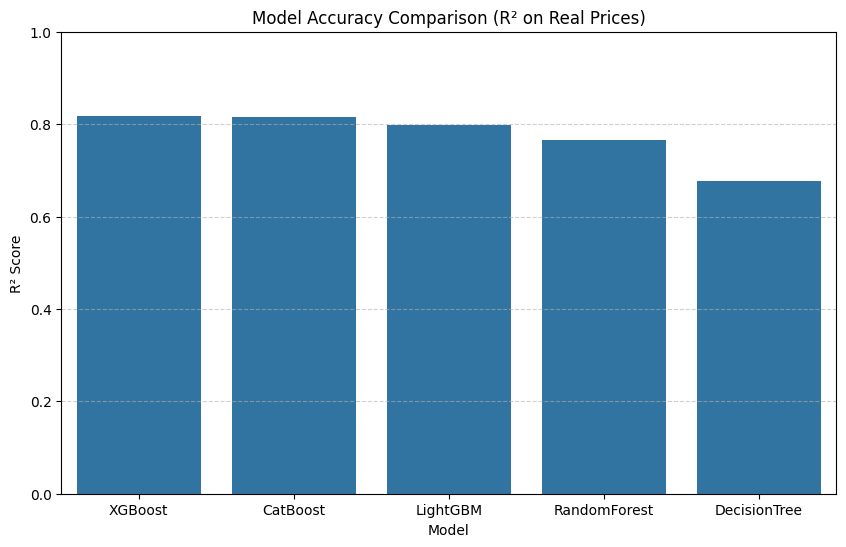

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=stress_df,
    x="model",
    y="R2_real"
)

plt.title("Model Accuracy Comparison (R² on Real Prices)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

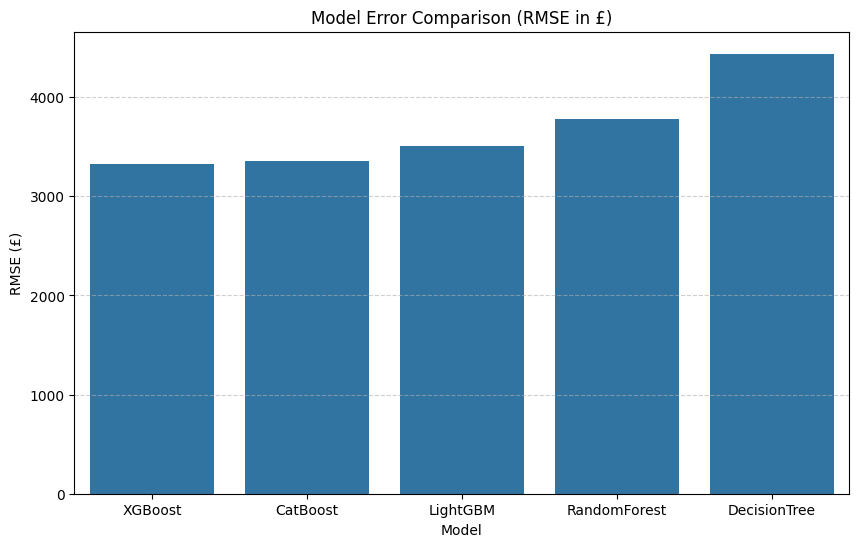

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=stress_df,
    x="model",
    y="RMSE_real"
)

plt.title("Model Error Comparison (RMSE in £)")
plt.xlabel("Model")
plt.ylabel("RMSE (£)")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

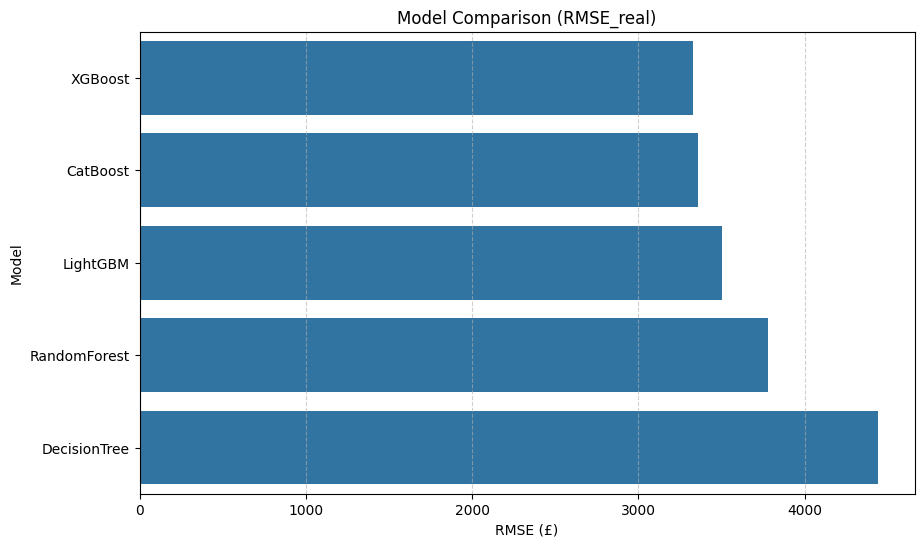

In [10]:
stress_sorted = stress_df.sort_values("RMSE_real")

plt.figure(figsize=(10,6))

sns.barplot(
    data=stress_sorted,
    x="RMSE_real",
    y="model"
)

plt.title("Model Comparison (RMSE_real)")
plt.xlabel("RMSE (£)")
plt.ylabel("Model")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

## Calibration Plot

A calibration plot was used to compare the **mean predicted price** and **mean actual price** on the real price scale.

For each model:

- predictions were converted from log scale back to real prices
- predicted values were divided into 10 quantile-based bins
- the average predicted and actual price was calculated for each bin

The dashed diagonal line represents perfect calibration.  
Curves close to this line indicate that the model’s predictions are well aligned with real market prices.

This helps evaluate whether a model is not only accurate, but also **reliable across different price ranges**, revealing possible underprediction or overprediction patterns.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



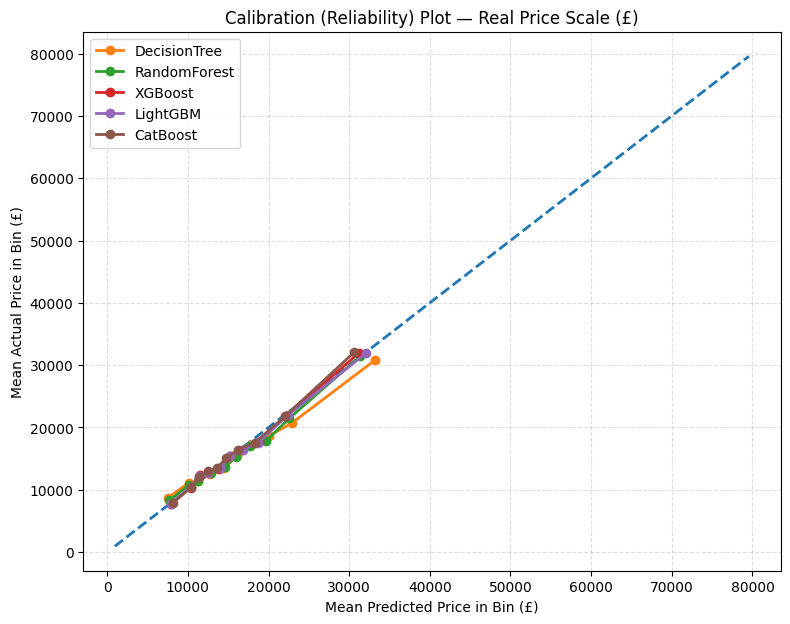

In [11]:
# Convert true values from log-scale back to real price scale
y_true_real = np.expm1(y_test.to_numpy())

# Store predictions for each model (in real price scale)
preds_real = {}

for name, reg in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", reg),
    ])
    
    # Train model
    pipe.fit(X_train, y_train)
    
    # Predict in log space, then convert back to real prices
    y_pred_log = pipe.predict(X_test)
    preds_real[name] = np.expm1(np.array(y_pred_log))

# Number of bins for calibration
n_bins = 10

plt.figure(figsize=(9, 7))

# Ideal calibration line (perfect predictions: y = x)
mn = float(np.min(y_true_real))
mx = float(np.max(y_true_real))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)

# Plot calibration curves for each model
for name, y_pred_real in preds_real.items():
    tmp = pd.DataFrame({
        "y_true": y_true_real,
        "y_pred": y_pred_real
    })

    # Create bins based on predicted values (quantile-based)
    tmp["bin"] = pd.qcut(tmp["y_pred"], q=n_bins, duplicates="drop")

    # Compute average predicted vs actual values per bin
    b = tmp.groupby("bin", observed=True).agg(
        mean_pred=("y_pred", "mean"),
        mean_true=("y_true", "mean"),
        count=("y_true", "size")
    ).reset_index()

    # Plot calibration curve
    plt.plot(b["mean_pred"], b["mean_true"], marker="o", linewidth=2, label=name)

# Plot formatting
plt.title("Calibration (Reliability) Plot — Real Price Scale (£)")
plt.xlabel("Mean Predicted Price in Bin (£)")
plt.ylabel("Mean Actual Price in Bin (£)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.show()

## Calibration Analysis (Real Price Scale)

The calibration plot shows how predicted prices compare to actual prices across different price ranges.

### Key Observations

- All models follow the diagonal closely in the **mid-price range**, indicating good overall calibration.

- In the **lower and mid segments**, all models behave similarly with small deviations.

- In the **higher price range (luxury segment)**:
  - **LightGBM shows the most stable and smooth curve**
  - Predictions remain closer to a consistent trend across bins
  - Less fluctuation compared to other models

- Other models (especially DecisionTree and RandomForest) show:
  - more irregular jumps between bins
  - higher sensitivity to sample variation in extreme price ranges

### Key Insight

- **LightGBM demonstrates better stability across price segments**, especially:
  - standard cars (mid-range)
  - luxury cars (high-range)

- This suggests:
  - smoother function approximation
  - less overreaction to noise in sparse regions (e.g. expensive cars)

### Interpretation

Even though LightGBM is not the top model in RMSE:

- it provides **more consistent predictions across the full price distribution**
- it behaves more reliably in **data-scarce regions (luxury vehicles)**

### Conclusion

- **CatBoost / XGBoost → better raw accuracy**
- **LightGBM → better calibration stability across segments**

This highlights an important trade-off:

> A model can be slightly less accurate overall but more reliable across different parts of the data distribution.